In [13]:
import xarray as xr
import pygmt
import numpy as np
#import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from gplately import Points, PlateReconstruction
#import geopandas as gpd
#from shapely.geometry import Point, LineString
from plate_model_manager import PlateModelManager

pygmt.config(#FONT="12p,Palatino-Roman", 
            FONT_ANNOT_PRIMARY="8p,Arial",
            FONT_ANNOT_SECONDARY="8p,Arial",
            FONT_LABEL="8p,Arial",
            IO_SEGMENT_MARKER="<<<",
            MAP_FRAME_TYPE = 'plain',
            FORMAT_GEO_MAP = 'D'
            )

gmtset [WARNING]: Representation of font type not recognized. Using default.
gmtset [WARNING]: Representation of font type not recognized. Using default.
gmtset [WARNING]: Representation of font type not recognized. Using default.


In [14]:
# pm_manager = PlateModelManager()
# pm_manager.get_available_model_names()

In [15]:
cpt_lines_litho = [
    "# Sample .cpt file",
    "# COLOR_MODEL = RGB",
    #
    "-5 255 215 0 -1  255 215 0",    #golden-white
    "-1 255 255 255 2 255 255 255",   #white-lightblue
    "2 173 216 230 5 173 216 230",    #lightblue-cornflowerblue
    "5 100 149 237 6 100 149 237",  #cornflowerblue-blue
    "6 0 0 255 7 0 0 255",   #blue-purple
    "7 128 0 128 8 128 0 128",    #purple
    "B 255 215 0",  # Background
    "F 128 0 128",   # Foreground (NaNs)
    "N 255 255 255"    # No data
]

with open("litho.cpt", "w") as f:
    f.write("\n".join(cpt_lines_litho))
    
cpt_lines_mtz = [
    "# Sample .cpt file",
    "# COLOR_MODEL = RGB",
    #
    "-5 255 215 0 -1 255 215 0",    #golden-white
    "-1 255 255 255 1 255 255 255",   #white-lightblue
    "1 173 216 230 2 173 216 230",    #lightblue-cornflowerblue
    "2 100 149 237 3 100 149 237",  #cornflowerblue-blue
    "3 0 0 255 4 0 0 255",   #blue-purple
    "4 128 0 128 5 128 0 128",    #purple
    "B 255 255 255",  # Background
    "F 255 255 255",   # Foreground (NaNs)
    "N 255 255 255"    # No data
]

with open("mtz.cpt", "w") as f:
    f.write("\n".join(cpt_lines_mtz))

In [16]:
# Request Matthews2016 from GPlately
pm_manager = PlateModelManager()

plate_model_ref = "Muller2016"
plate_model = pm_manager.get_model(plate_model_ref, data_dir="plate-model-repo")
#muller2016_model = pm_manager.get_model("Muller2016", data_dir="plate-model-repo")

rotation_model = plate_model.get_rotation_model()
topology_features = plate_model.get_topologies()
static_polygons = plate_model.get_static_polygons()

coastlines = plate_model.get_layer('Coastlines')

# Call the PlateReconstruction object to create a plate motion model
recon_model_mu = PlateReconstruction(rotation_model, topology_features, static_polygons)

plate_model_ref = "Matthews2016"
plate_model = pm_manager.get_model(plate_model_ref, data_dir="plate-model-repo")
#muller2016_model = pm_manager.get_model("Muller2016", data_dir="plate-model-repo")

rotation_model = plate_model.get_rotation_model()
topology_features = plate_model.get_topologies()
static_polygons = plate_model.get_static_polygons()

coastlines = plate_model.get_layer('Coastlines')
# Call the PlateReconstruction object to create a plate motion model
recon_model_ma = PlateReconstruction(rotation_model, topology_features, static_polygons)

# # Call the PlotTopologies object
#gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=None, COBs=None, time=0)

In [ ]:
#or shape reconstruction
data = np.loadtxt("contour_2.txt")
lons, lats = data[:, 0], data[:, 1]
#lons, lats = -40, -25 #test for Tristan
# Plate IDs
moving_plate_ID = 1     #Atlantic reference frame
anchor_plate_ID = 201   #South America Plate

# Create the time array for the motion path - must be float
start_reconstruction_time = 0.
time_step = 10.
max_reconstruction_time = 200.
time_array = np.arange(start_reconstruction_time, max_reconstruction_time + time_step, time_step)

# Get the latitudes and longitudes of all points along the motion path
rlons_mu, rlats_mu, rtimes, rates_of_motion = recon_model_mu.create_motion_path(
    lons,
    lats,
    time_array,
    # Specify the reconstruction time...
    to_time=0,
    plate_id=moving_plate_ID,
    anchor_plate_id=anchor_plate_ID,
    return_times=True,
    return_rate_of_motion=True)

# Get the latitudes and longitudes of all points along the motion path
rlons_ma, rlats_ma, rtimes, rates_of_motion = recon_model_ma.create_motion_path(
    lons,
    lats,
    time_array,
    # Specify the reconstruction time...
    to_time=0,
    plate_id=moving_plate_ID,
    anchor_plate_id=anchor_plate_ID,
    return_times=True,
    return_rate_of_motion=True)

In [18]:
# Assuming your input lons and lats are arrays of N points, and time_array contains T time steps
# (e.g., 14 if going 0 → 130 Ma by 10 Ma), the output shapes are:
# rlons: shape (N, T)
# rlats: shape (N, T)
# rtimes: shape (T,) or (N, T)
def extract_reconstructed_coords_at_time(rlons, rlats, rtimes, target_time):
    """
    Extract reconstructed coordinates from motion path arrays at a specific reconstruction time.

    Parameters:
    - rlons, rlats: Arrays of shape (N, T) from create_motion_path()
    - rtimes: Array of time steps used in create_motion_path()
    - target_time: Desired time (e.g., 80.0) in Myr

    Returns:
    - lons_at_time, lats_at_time: Arrays of shape (N,) with reconstructed positions
    """
    rtimes = np.asarray(rtimes)
    if rtimes.ndim == 2:
        rtimes = rtimes[0]  # Assume all points share the same time steps

    # Find index of closest time step
    idx = np.argmin(np.abs(rtimes - target_time))
    actual_time = rtimes[idx]

    print(f"Closest available time to {target_time} Ma is {actual_time} Ma (index {idx})")

    return rlons[:, idx], rlats[:, idx]

# lons_200Ma, lats_200Ma = extract_reconstructed_coords_at_time(rlons_ma, rlats_ma, rtimes, 200.0)
# lons_130Ma, lats_130Ma = extract_reconstructed_coords_at_time(rlons_ma, rlats_ma, rtimes, 135.0)
# lons_90Ma, lats_90Ma = extract_reconstructed_coords_at_time(rlons_ma, rlats_ma, rtimes, 90.0)

lons_200Mu, lats_200Mu = extract_reconstructed_coords_at_time(rlons_mu, rlats_mu, rtimes, 200.0)
lons_130Mu, lats_130Mu = extract_reconstructed_coords_at_time(rlons_mu, rlats_mu, rtimes, 135.0)
lons_90Mu, lats_90Mu = extract_reconstructed_coords_at_time(rlons_mu, rlats_mu, rtimes, 85.0)
#print(lons_130Ma)


Closest available time to 200.0 Ma is 200.0 Ma (index 10)
Closest available time to 135.0 Ma is 130.0 Ma (index 3)
Closest available time to 85.0 Ma is 100.0 Ma (index 0)


In [19]:
def extract_dvs(ds, depth):
    """
    Extract dVs values for a given depth from the netCDF dataset.
    """
    slice_dvs = ds['dVs'].sel(depth=depth, method='nearest')
    #Check which depth was actually selected (optional)
    actual_depth = slice_dvs.depth.values
    print(f"Selected depth: {actual_depth} km")
    slice_dvs_scaled = slice_dvs*100
    refined_grid = pygmt.grdsample(
        grid=slice_dvs_scaled,       # your xarray.DataArray
        spacing="0.05/0.05",    # target resolution in degrees (lon/lat)
        registration="g",     # gridline registration (default)
        #method="linear"            # linear interpolation
    )
    return refined_grid

def contour_dvs(slice):
    # Convert to 2D NumPy arrays
    lon = slice['x'].values
    lat = slice['y'].values
    data = slice.values
    
    # Make the contour
    fig, ax = plt.subplots()
    contour = ax.contour(lon, lat, data, levels=[0.9, 2]);
    plt.close(fig)
    # Extract contour paths
    contour_paths = []
    for collection in contour.collections:
        for path in collection.get_paths():
            contour_paths.append(path.vertices)  # ndarray of shape (n_points, 2)
            
    with open("contour_2.txt", "w") as f:
        for segment in contour_paths:
            #f.write("> -Z2\n")  # GMT segment header
            np.savetxt(f, segment, fmt="%.6f")
            
    return contour_paths


Selected depth: 150.0 km


text [WARNING]: Representation of font type not recognized. Using default.
plot [WARNING]: Your data array row 83 contains NaNs - no resampling taken place!


Selected depth: 485.0 km


/var/folders/3d/knlgjz2d4p7fb202r38kmdgh0000gn/T/ipykernel_86579/1542766032.py:30: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
text [WARNING]: Representation of font type not recognized. Using default.
plot [WARNING]: Your data array row 83 contains NaNs - no resampling taken place!


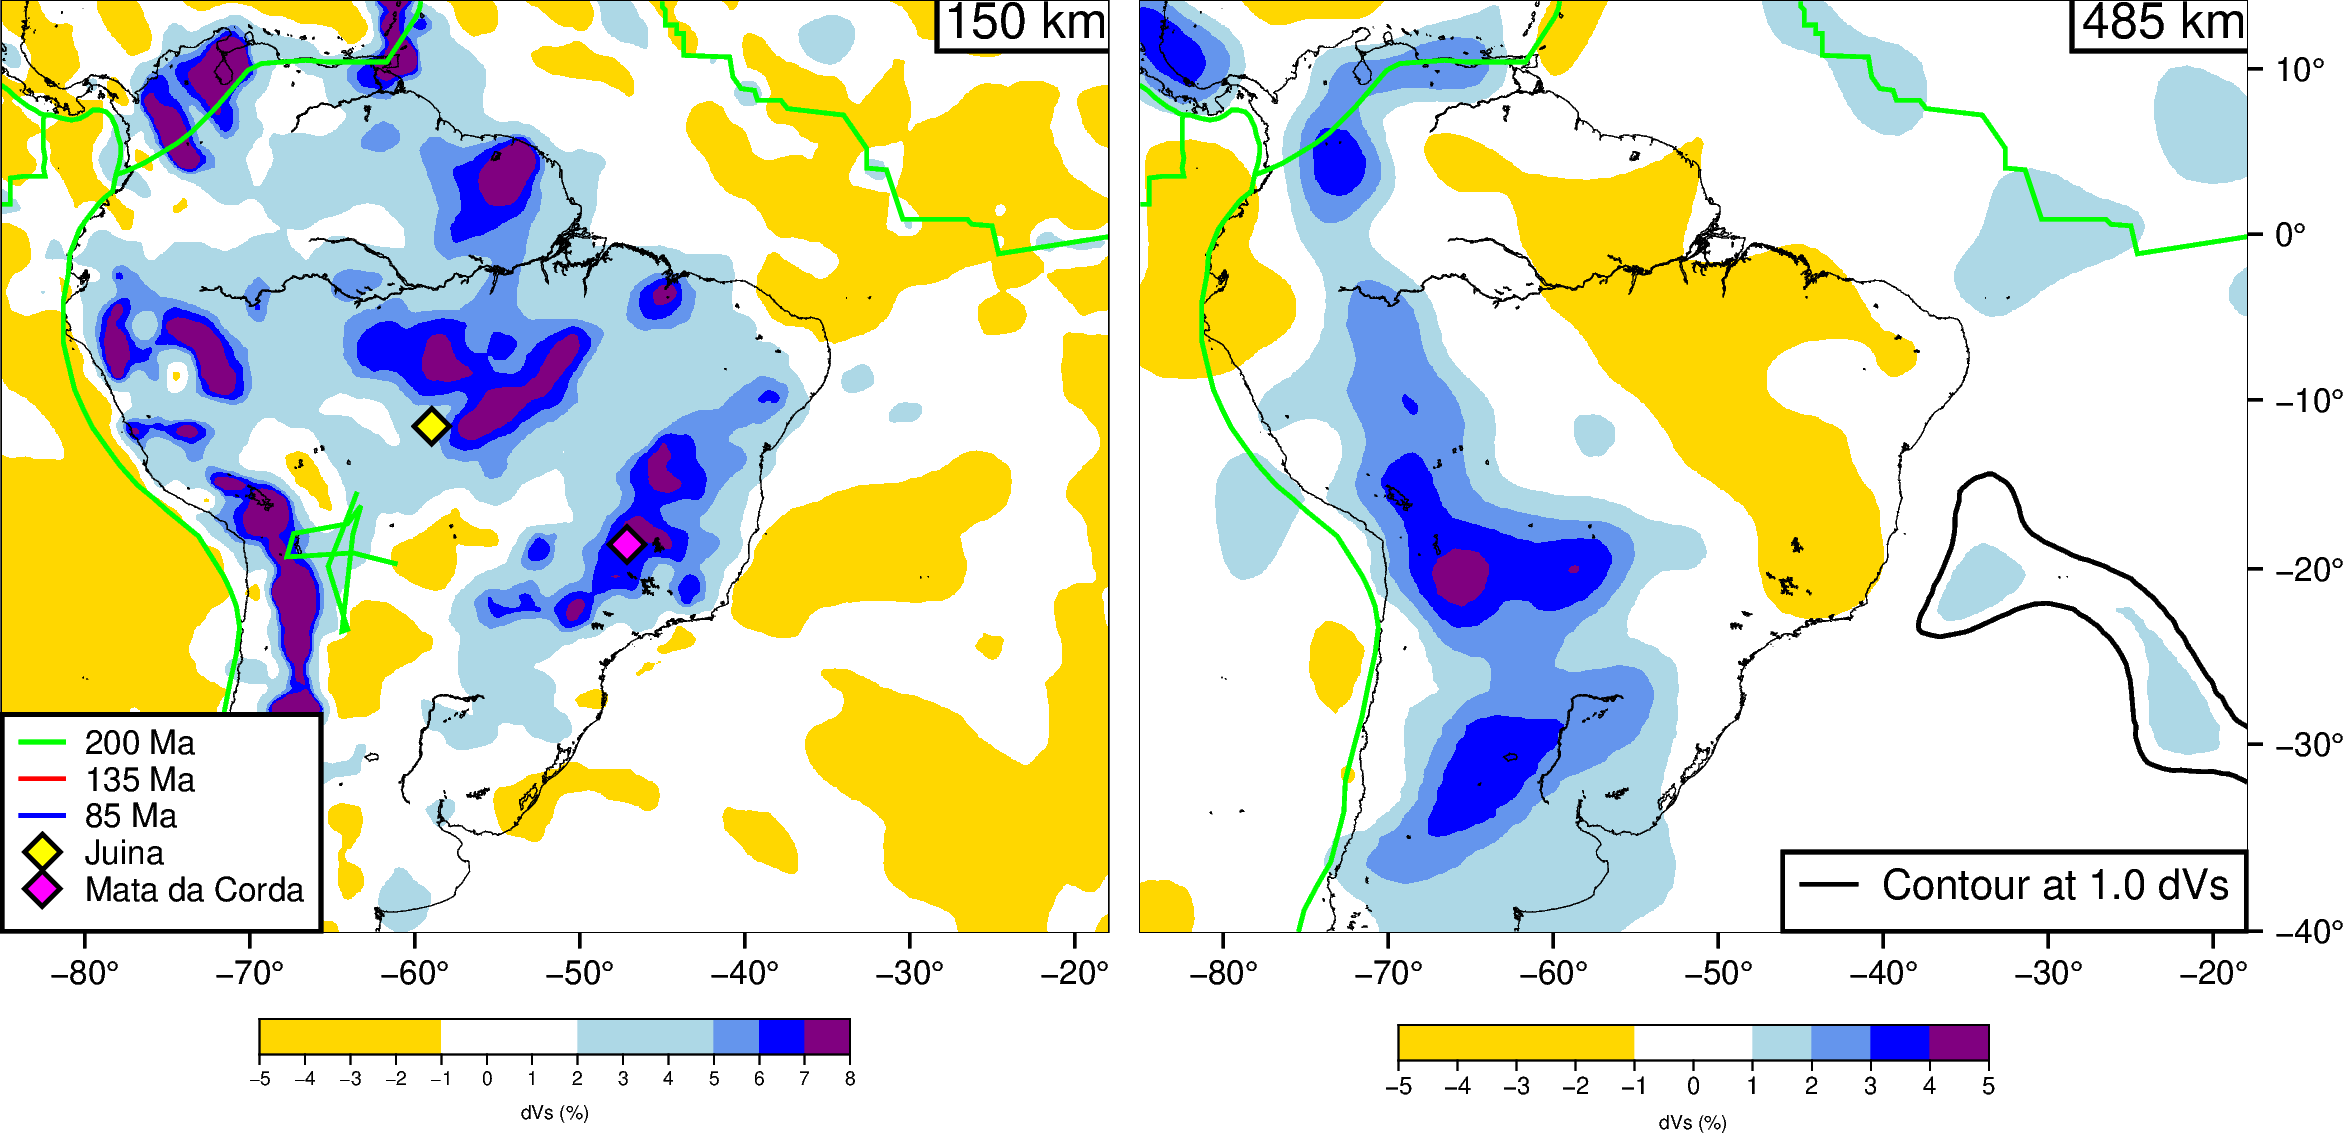

In [20]:
nc = xr.open_dataset('../../../data/seismic_model/SACI-24.nc')
region = [-85,-18,-40,14]  # [west, east, south, north]

fig = pygmt.Figure()

with fig.subplot(
    nrows=1, 
    ncols=2,
    figsize=("19c", "8c"),
    #dpi="300",
    sharex="b",
    sharey="r",
    frame=["a10", "lrbt"]):
    
    with fig.set_panel(panel=0):
        dep=150
        fig.basemap(
            region=region,
            projection="J?",
        )
        
        grid = extract_dvs(nc, dep)
        
        fig.grdimage(grid=grid, cmap="litho.cpt")
        fig.coast(
            shorelines="0.2p,black",
            #borders="0.5p,black",
            resolution="h"
        )
        fig.text(position='TR', text=str(dep) + " km", clearance="0.1c", fill="white", font="12p,Arial,black", pen="1p,black")
        fig.colorbar(
            frame=["a1","x+ldVs (%)"],
            position="JBC+w5c/0.3c+h"
        )
        fig.plot(
            data="../../../data/plate_boundaries/nuvel1.txt",
            pen="1p,green"
        )
        # fig.plot(x=lons_200Ma, y=lats_200Ma, pen="1p,green,--", label="200 Ma Matthews (2016)")
        # fig.plot(x=lons_130Ma, y=lats_130Ma, pen="1p,red,--", label="135 Ma Matthews (2016)")
        # fig.plot(x=lons_90Ma, y=lats_90Ma, pen="1p,blue,--", label="90 Ma Matthews (2016)")
        #fig.plot(x=lons_200Mu, y=lats_200Mu, pen="1p,green", label="200 Ma")
        fig.plot(x=rlons_mu[0], y=rlats_mu[0], pen="1p,green", label="200 Ma")
        fig.plot(x=lons_130Mu, y=lats_130Mu, pen="1p,red", label="135 Ma")
        fig.plot(x=lons_90Mu, y=lats_90Mu, pen="1p,blue", label="85 Ma")
        #transfo#transform=ccrs.PlateCarree())
        fig.plot(x=-58.95, y=-11.6, style="d0.3c", fill="yellow", pen="1p,black", label="Juina")
        fig.plot(x=-47.12, y=-18.6, style="d0.3c", fill="magenta", pen="1p,black", label="Mata da Corda")
        fig.legend(position="jBL", box="+gwhite+p1p" )# Example point
    with fig.set_panel(panel=1):
        dep=485
        #pygmt.makecpt(cmap="custom.cpt", )
        grid = extract_dvs(nc, dep)
        clipped = pygmt.grdcut(grid=grid, region=[-45, -10, -40, -12])
        contour = contour_dvs(clipped)
        fig.basemap(
            region=region,
            projection="J?",
        )
        fig.grdimage(grid=grid, cmap="mtz.cpt")
        fig.coast(
            shorelines="0.2p,black", 
            #borders="0.5p,black",
            resolution="h"
        )
        fig.text(position='TR', text=str(dep) + " km", clearance="0.1c", fill="white", font="12p,Arial,black", pen="1p,black")
        pygmt.config(FONT_ANNOT_PRIMARY="10p")
        fig.colorbar(
            frame=["a1","x+ldVs (%)"],
            position="JBC+w5c/0.3c+h",
            #annotation="8p"
        )
        fig.plot(
            data="../../../data/plate_boundaries/nuvel1.txt",
            pen="1p,green"
        )
        fig.plot(data="contour_2.txt", pen="1p,black", label="Contour at 1.0 dVs")
        fig.legend(position="jBR", box="+gwhite+p1p")# Example point
fig.show()
fig.savefig("litho-reconstruction.png", dpi=300, transparent=True, crop=True)